In [30]:
#
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from specgen import spectrum_PM, spectrum_gen_linear, eta_random, spectrum_PM_piece
#
#P    = 0.0016/6.4;  #kpHs=0.04        # energy level (estimated so that kpHs is reasonable)
#P = 0.0064/6.4;  #kpHs=0.08
P = 0.025/6.4 #kpHs=0.16
Bo_1 = 200;
Bo_2 = 1
N  = 4
L  = 2.0*np.pi    # domain size
kp = 2*np.pi/(L/N)    # peak wavenumber
N_mode  = 64 # number of modes
N_power = 5   # directional spreading coeff
k_cf = (kp**2*Bo_1/Bo_2)**0.5
print(k_cf);
#

56.568542494923804


In [31]:
#
def shape(kmod):
    ''' Choose values here '''
    global P, kp
    #F_kmod = spectrum_PM (P, kp, kmod);
    F_kmod = spectrum_PM_piece (P, kp, k_cf, kmod);
    #F_kmod = spectrum_PM(P, kp, kmod)
    return F_kmod
#
kmod, F_kmod, kx, ky, F_kxky_tile = spectrum_gen_linear(
    shape, N_mode=N_mode, L=L, N_power=N_power)
#
''' Generate a grid in x-y to visualize random eta '''
N_grid = 256  # L = 200
x = np.linspace(-L/2, L/2, N_grid)
y = np.linspace(-L/2, L/2, N_grid)
x_tile, y_tile = np.meshgrid(x, y)
kx_tile, ky_tile = np.meshgrid(kx, ky)
t = 0
eta_tile, phase_tile = eta_random(
    t, kx_tile, ky_tile, F_kxky_tile, x_tile, y_tile)
kpHs = kp*np.std(eta_tile)*4;
print('kpHs = %g' % (kpHs));
#

kpHs = 0.160351


[  1.           3.23809524   5.47619048   7.71428571   9.95238095
  12.19047619  14.42857143  16.66666667  18.9047619   21.14285714
  23.38095238  25.61904762  27.85714286  30.0952381   32.33333333
  34.57142857  36.80952381  39.04761905  41.28571429  43.52380952
  45.76190476  48.          50.23809524  52.47619048  54.71428571
  56.95238095  59.19047619  61.42857143  63.66666667  65.9047619
  68.14285714  70.38095238  72.61904762  74.85714286  77.0952381
  79.33333333  81.57142857  83.80952381  86.04761905  88.28571429
  90.52380952  92.76190476  95.          97.23809524  99.47619048
 101.71428571 103.95238095 106.19047619 108.42857143 110.66666667
 112.9047619  115.14285714 117.38095238 119.61904762 121.85714286
 124.0952381  126.33333333 128.57142857 130.80952381 133.04761905
 135.28571429 137.52380952 139.76190476 142.        ]
[2.06115362e-12 4.37260976e-06 3.12554133e-06 1.55652655e-06
 8.28947365e-07 4.82491362e-07 3.02418083e-07 2.00994673e-07
 1.39953155e-07 1.01176195e-07 7.5

Text(120, 5e-10, '$k_cL_0\\approx 352$')

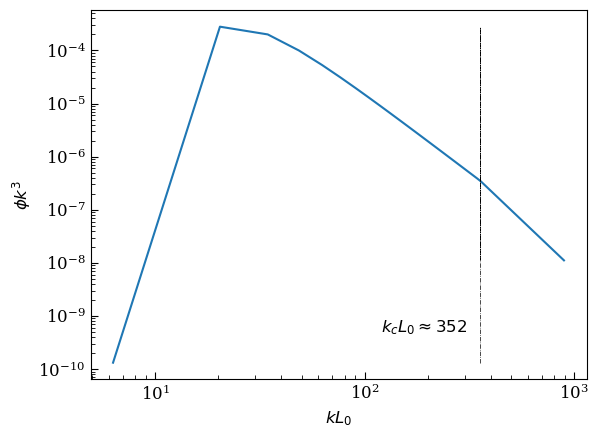

In [24]:
#
do_show = 0;
cm = 1.0/2.54;
wid = 10.0;
hei = 8.5;
st_diss = 50;
size_bib = 8;
size_tit = 14;
line_width = 0.9;
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = "serif"
tdir = 'in'
major = 5.0
minor = 3.0
plt.rcParams['xtick.direction'] = tdir
plt.rcParams['ytick.direction'] = tdir
plt.rcParams['xtick.major.size'] = major
plt.rcParams['xtick.minor.size'] = minor
plt.rcParams['ytick.major.size'] = major
plt.rcParams['ytick.minor.size'] = minor
#
L0 = 2.0*np.pi; kp = 4;
print(kmod)
print(F_kmod)
#plt.xscale('log',base=10)
#plt.yscale('log',base=10) 
plt.loglog(kmod*L0,F_kmod*kp**3);
plt.xlabel(r"$kL_0$");
plt.ylabel(r"$\phi k^3$")
xc = k_cf*np.ones([len(F_kmod)]);
plt.plot(xc*L0,F_kmod*kp**3,'k-.',linewidth=0.5);
plt.annotate(r"$k_cL_0\approx 352$", xy=(120, 0.5e-9))

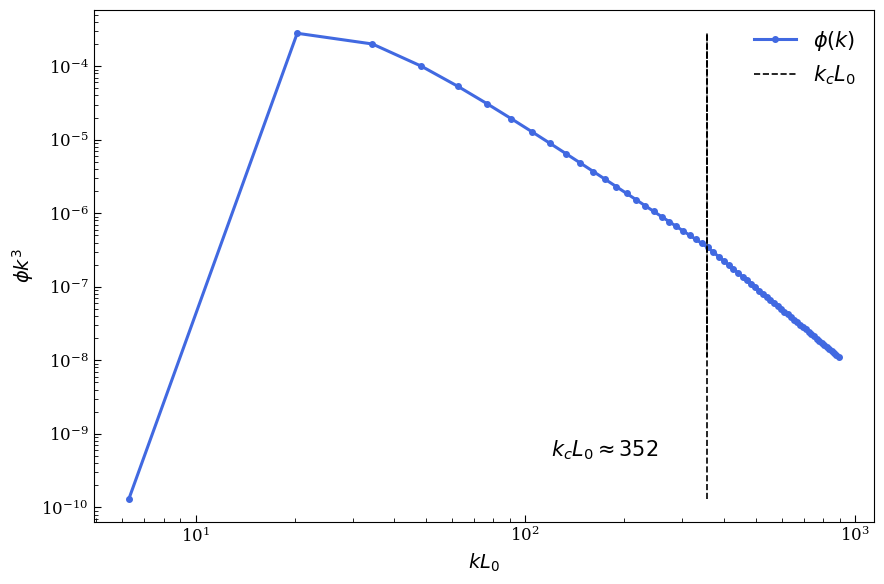

In [25]:
plt.figure(figsize=(9,6))

# --- Curva principal ---
plt.loglog(kmod * L0, F_kmod * kp**3, 'o-', color='royalblue', markersize=4, linewidth=2.2, label=r'$\phi(k)$')

# --- Línea vertical en k_c ---
xc = k_cf * np.ones_like(F_kmod)
plt.plot(xc * L0, F_kmod * kp**3, 'k--', linewidth=1.2, label=r'$k_cL_0$')

# --- Anotación elegante ---
plt.annotate(
    r"$k_cL_0 \approx 352$",
    xy=(120, 0.5e-9),
    fontsize=15,
)

# --- Etiquetas y formato ---
plt.xlabel(r"$kL_0$", fontsize=14)
plt.ylabel(r"$\phi k^3$", fontsize=14)
#plt.grid(True, which='both', ls='--', alpha=0.4)
plt.legend(frameon=False, fontsize=15, loc ='upper right')
plt.tight_layout()
plt.savefig("initial_spectra.pdf", dpi=300, bbox_inches='tight')
plt.show()

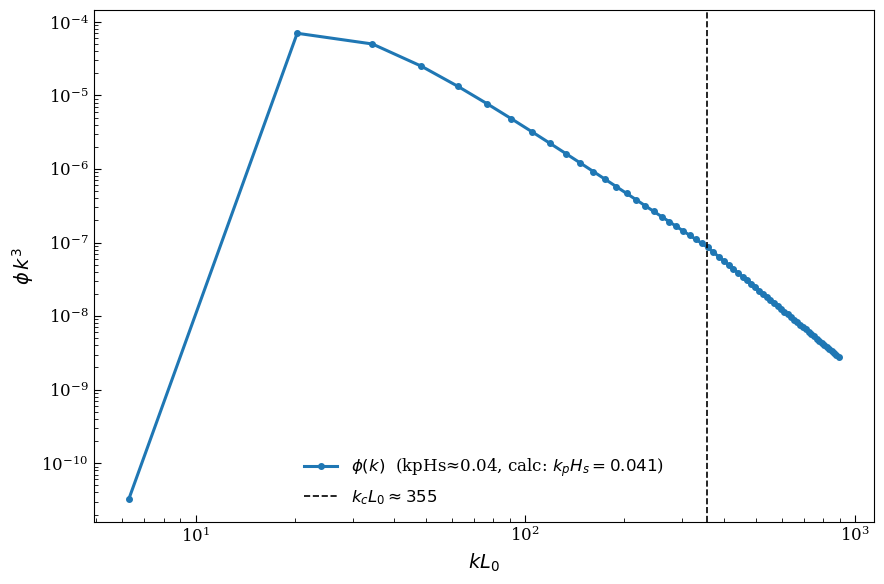

Guardado: initial_spectra_kpHs~0.04.pdf


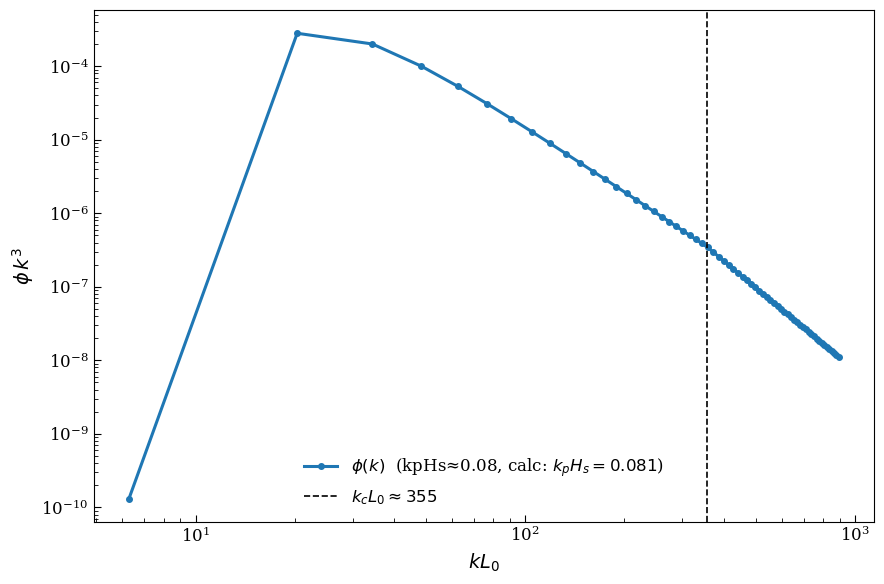

Guardado: initial_spectra_kpHs~0.08.pdf


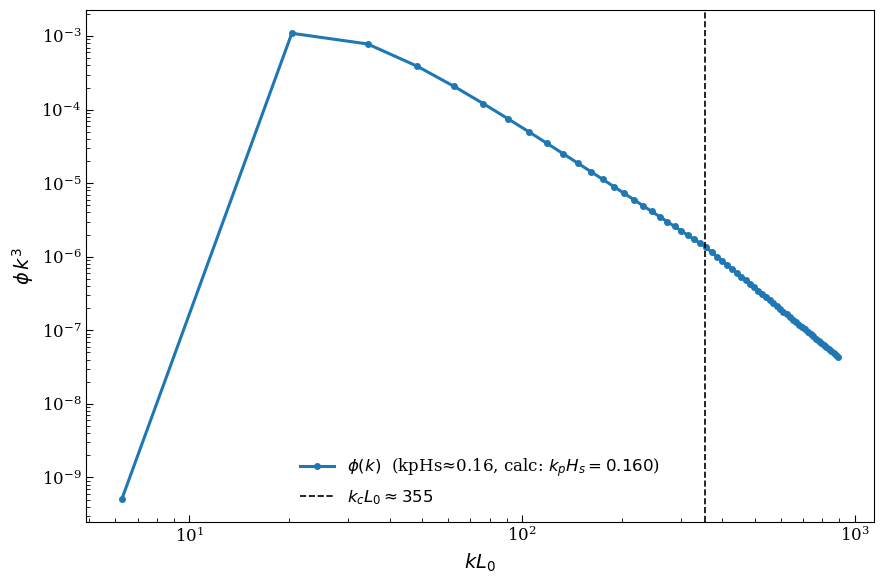

Guardado: initial_spectra_kpHs~0.16.pdf


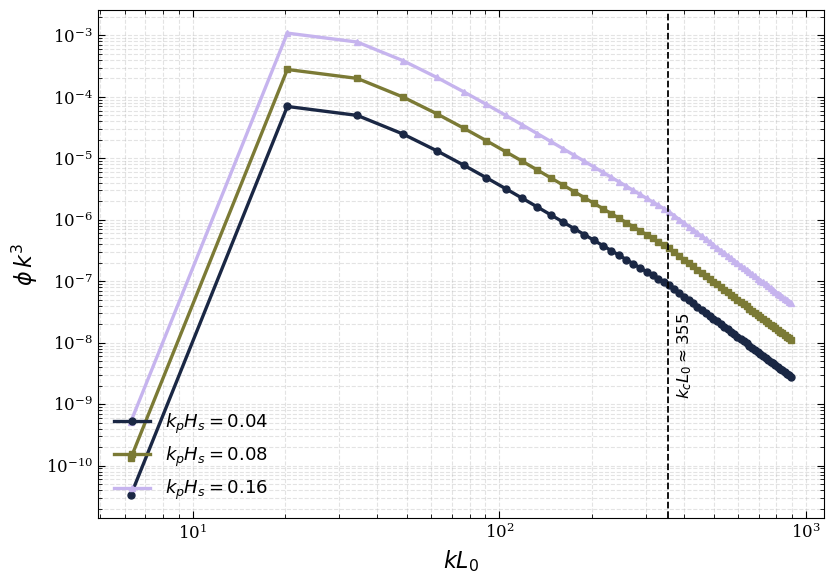

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from specgen import spectrum_PM_piece, spectrum_gen_linear, eta_random


Bo_1, Bo_2 = 200, 1
N  = 4
L  = 2.0*np.pi          # domain size
kp = 2*np.pi/(L/N)      # peak wavenumber (no lo sobreescribimos a 4)
N_mode  = 64
N_power = 5
k_cf = (kp**2 * Bo_1 / Bo_2)**0.5
L0 = L                   # para el eje kL0 en la figura

cases = [
    {"P": 0.0016/6.4, "tag": "kpHs≈0.04"},
    {"P": 0.0064/6.4, "tag": "kpHs≈0.08"},
    {"P": 0.0250/6.4, "tag": "kpHs≈0.16"},
]

def generate_case(P, seed=0):
    def shape(kmod):
        return spectrum_PM_piece(P, kp, k_cf, kmod)

    kmod, F_kmod, kx, ky, F_kxky_tile = spectrum_gen_linear(
        shape, N_mode=N_mode, L=L, N_power=N_power
    )

    N_grid = 256
    x = np.linspace(-L/2, L/2, N_grid)
    y = np.linspace(-L/2, L/2, N_grid)
    x_tile, y_tile = np.meshgrid(x, y)
    kx_tile, ky_tile = np.meshgrid(kx, ky)

    rng_state = np.random.get_state()
    np.random.seed(seed)
    eta_tile, phase_tile = eta_random(0.0, kx_tile, ky_tile, F_kxky_tile, x_tile, y_tile)
    np.random.set_state(rng_state)

    kpHs_val = kp * (np.std(eta_tile) * 4.0)
    return kmod, F_kmod, kpHs_val

all_results = []
for i, c in enumerate(cases, start=1):
    P = c["P"]
    kmod, F_kmod, kpHs_val = generate_case(P, seed=42+i)
    c["kmod"] = kmod
    c["F_kmod"] = F_kmod
    c["kpHs"] = kpHs_val
    all_results.append(c)

    plt.figure(figsize=(9, 6))
    plt.loglog(kmod * L0, F_kmod * kp**3, 'o-', linewidth=2.2, markersize=4,
               label=rf'$\phi(k)$  ({c["tag"]}, calc: $k_pH_s={kpHs_val:.3f}$)')

    # línea vertical en k_c (mismo k_c para todos los P)
    plt.axvline(k_cf * L0, ls='--', color='k', linewidth=1.2, label=rf'$k_cL_0 \approx {k_cf*L0:.0f}$')

    plt.xlabel(r"$kL_0$", fontsize=14)
    plt.ylabel(r"$\phi\,k^3$", fontsize=14)
    plt.legend(frameon=False, fontsize=12, loc='best')
    plt.tight_layout()
    outname = f"initial_spectra_{c['tag'].replace('≈','~').replace(' ','')}.pdf"
    plt.savefig(outname, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Guardado: {outname}")

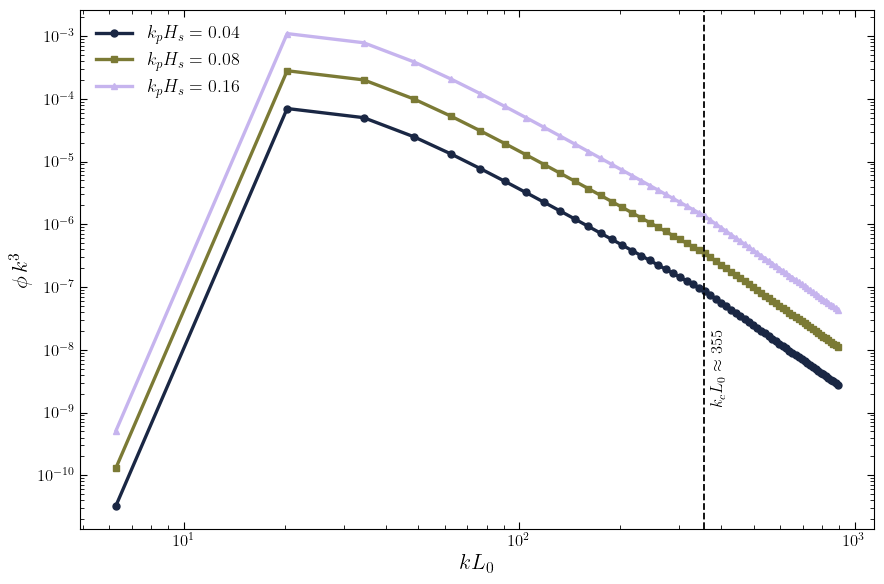

In [38]:
# ===== Figura comparativa (las tres curvas juntas) =====
import pylab

params = {'legend.fontsize': 'xx-Large',
          'figure.figsize': (9, 6),
         'axes.labelsize': 30,
         'axes.titlesize':30,
         'xtick.labelsize':30,
         'ytick.labelsize':30,
    'font.family': 'STIXGeneral', 
    'axes.titleweight': 'normal',
    'axes.labelweight': 'normal',
    'text.usetex': True, # Enable LaTeX rendering
}

plt.rcParams.update(params)
pylab.rcParams.update(params)
# paleta continua (cubehelix o viridis suave)
colors = plt.cm.cubehelix(np.linspace(0.15, 0.75, len(all_results)))

# trazo cada espectro con color y marcador distinto
MARKERS = ['o', 's', '^']
for i, c in enumerate(all_results):
    kmod = c["kmod"]; F_kmod = c["F_kmod"]; kpHs_val = c["kpHs"]
    plt.loglog(
        kmod * L0, F_kmod * kp**3,
        lw=2.4, marker=MARKERS[i % len(MARKERS)], ms=5,
        color=colors[i],
        label=rf'$k_pH_s={kpHs_val:.2f}$'
    )

# línea vertical para kcL0
plt.axvline(k_cf * L0, ls='--', color='k', lw=1.3)
plt.text(k_cf * L0 * 1.05, 1.2e-9, rf'$k_cL_0 \approx {k_cf*L0:.0f}$',
         rotation=90, va='bottom', ha='left', fontsize=12)

# ejes y formato
plt.xlabel(r"$kL_0$", fontsize=16)
plt.ylabel(r"$\phi\,k^3$", fontsize=16)
plt.tick_params(which='both', direction='in', top=True, right=True, labelsize=12)
#plt.grid(True, which='both', ls='--', alpha=0.35)

# leyenda fuera del gráfico
plt.legend(frameon=False, fontsize=13, loc='upper left')

# estética global
plt.rcParams['font.family'] = 'serif'
plt.tight_layout()
plt.savefig("initial_spectra_comparison.pdf", dpi=400, bbox_inches='tight')
plt.show()

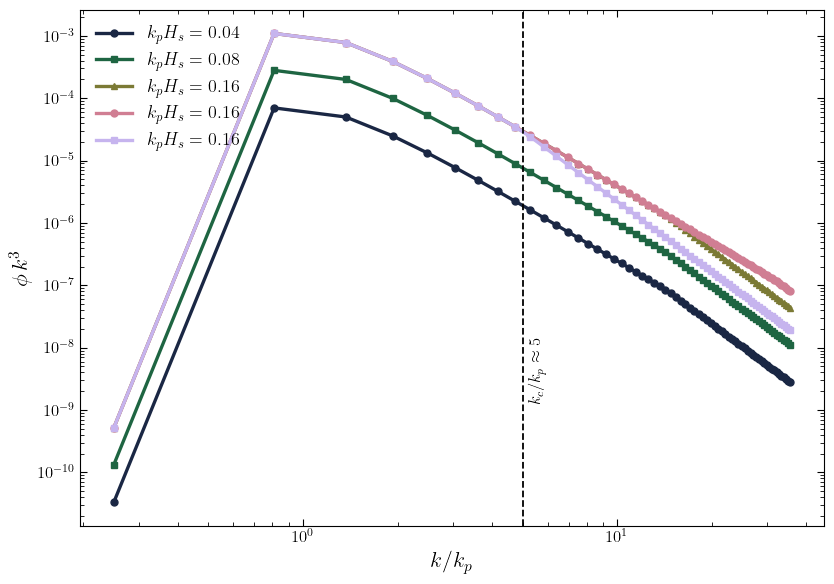

In [67]:
import numpy as np
import matplotlib.pyplot as plt

# ==== parámetros de estilo global ====
params = {
    'font.family': 'serif',
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 13,
    'lines.linewidth': 2.4,
    'figure.figsize': (8.5, 6)
}
plt.rcParams.update(params)

# ==== paleta continua ====
colors = plt.cm.cubehelix(np.linspace(0.15, 0.75, len(all_results)))
MARKERS = ['o', 's', '^']

# ==== plot ====
for i, c in enumerate(all_results):
    kmod = c["kmod"]
    F_kmod = c["F_kmod"]
    kpHs_val = c["kpHs"]

    plt.loglog(
        kmod / kp, F_kmod * kp**3,
        lw=2.4,
        marker=MARKERS[i % len(MARKERS)],
        ms=5,
        color=colors[i],
        label=rf'$k_pH_s={kpHs_val:.2f}$'
    )

# ==== línea vertical para kc/kp ====
kcf_ratio = k_cf / kp  # normalizada por kp
plt.axvline(kcf_ratio, ls='--', color='k', lw=1.3)
plt.text(kcf_ratio * 1.05, 1.2e-9, rf'$k_c/k_p \approx {kcf_ratio:.0f}$',
         rotation=90, va='bottom', ha='left', fontsize=12)

# ==== ejes y formato ====
plt.xlabel(r"$k/k_p$")
plt.ylabel(r"$\phi\,k^3$")
plt.tick_params(which='both', direction='in', top=True, right=True)
plt.legend(frameon=False, loc='upper left')

plt.tight_layout()
plt.savefig("initial_spectra_comparison_kp_norm.pdf", dpi=400, bbox_inches='tight')
plt.show()


In [39]:
import numpy as np
import matplotlib.pyplot as plt

# ===== Parámetros base (mantengo tu lógica) =====
Bo_2   = 1
N      = 4
L      = 2.0*np.pi        # domain size
kp     = 2*np.pi/(L/N)    # peak wavenumber
N_mode = 64
N_power= 5
L0     = L

# --- Casos: tres con Bo1=200 y dos adicionales con Bo1=1000 y 25 (todos a tu estilo) ---
cases = [
    # Bo1 = 200 (tres niveles de energía)
    {"Bo1": 200, "P": 0.0016/6.4, "tag": "Bo1=200, kpHs≈0.04"},
    {"Bo1": 200, "P": 0.0064/6.4, "tag": "Bo1=200, kpHs≈0.08"},
    {"Bo1": 200, "P": 0.0250/6.4, "tag": "Bo1=200, kpHs≈0.16"},
    # Nuevos casos: Bo1 = 1000 y 25 con el mismo nivel de energía que kpHs≈0.16
    {"Bo1": 1000, "P": 0.0250/6.4, "tag": "Bo1=1000, kpHs≈0.16"},
    {"Bo1": 25,   "P": 0.0250/6.4, "tag": "Bo1=25,  kpHs≈0.16"},
]

def generate_case(P, Bo1, seed=0):
    k_cf = np.sqrt(kp**2 * Bo1 / Bo_2)   # cutoff por caso

    def shape(kmod):
        return spectrum_PM_piece(P, kp, k_cf, kmod)

    kmod, F_kmod, kx, ky, F_kxky_tile = spectrum_gen_linear(
        shape, N_mode=N_mode, L=L, N_power=N_power
    )

    # calcular kpHs a partir de una realización de eta
    N_grid = 256
    x = np.linspace(-L/2, L/2, N_grid)
    y = np.linspace(-L/2, L/2, N_grid)
    x_tile, y_tile = np.meshgrid(x, y)
    kx_tile, ky_tile = np.meshgrid(kx, ky)

    rng_state = np.random.get_state()
    np.random.seed(seed)
    eta_tile, _ = eta_random(0.0, kx_tile, ky_tile, F_kxky_tile, x_tile, y_tile)
    np.random.set_state(rng_state)

    kpHs_val = kp * (np.std(eta_tile) * 4.0)
    return kmod, F_kmod, kpHs_val, k_cf

# === Ejecutar y guardar resultados por caso ===
all_results = []
for i, c in enumerate(cases, start=1):
    kmod, F_kmod, kpHs_val, k_cf = generate_case(c["P"], c["Bo1"], seed=40+i)
    c.update({"kmod": kmod, "F_kmod": F_kmod, "kpHs": kpHs_val, "k_cf": k_cf})
    all_results.append(c)

# === Figura comparativa: 5 curvas + líneas k_cL0 por cada Bo1 ===
plt.figure(figsize=(8.8, 6.2))
plt.rcParams['font.family'] = 'serif'

# Colores por Bo1, marcadores por nivel de P (aprox kpHs); así se distinguen grupos y energías
bo1_values = sorted(set(c["Bo1"] for c in all_results))
bo1_to_color = {b: col for b, col in zip(bo1_values, plt.cm.cubehelix(np.linspace(0.2, 0.8, len(bo1_values))))}

# marcadores por P (para que los tres de Bo1=200 se distingan entre sí)
unique_Ps = list(dict.fromkeys([c["P"] for c in all_results]))  # orden de aparición
MARKERS = ['o', 's', '^', 'D', 'v']  # suficientes para 5
P_to_marker = {P: MARKERS[i % len(MARKERS)] for i, P in enumerate(unique_Ps)}

for c in all_results:
    color = bo1_to_color[c["Bo1"]]
    marker = P_to_marker[c["P"]]
    label = rf'{c["tag"]} (calc: $k_pH_s={c["kpHs"]:.3f}$)'
    plt.loglog(
        c["kmod"] * L0, c["F_kmod"] * kp**3,
        lw=2.3, marker=marker, ms=5.2, color=color, label=label, alpha=0.95
    )

# Líneas verticales k_cL0: una por Bo1 (no por cada curva) para no saturar
for b in bo1_values:
    # toma el k_cf de cualquier caso con ese Bo1 (son iguales para mismo Bo1)
    kcf_L0 = next(c["k_cf"] * L0 for c in all_results if c["Bo1"] == b)
    plt.axvline(kcf_L0, ls='--', color=bo1_to_color[b], lw=1.4)
    plt.text(kcf_L0*1.03, plt.ylim()[1]*0.6, rf'$k_cL_0\;(Bo_1={b})\approx {kcf_L0:.0f}$',
             rotation=90, va='bottom', ha='left', fontsize=11, color=bo1_to_color[b])

plt.xlabel(r"$kL_0$", fontsize=16)
plt.ylabel(r"$\phi\,k^3$", fontsize=16)
plt.tick_params(which='both', direction='in', top=True, right=True, labelsize=12)
plt.grid(True, which='both', ls='--', alpha=0.35)
plt.legend(frameon=False, fontsize=11, loc='best', ncol=1)
plt.tight_layout()
plt.savefig("initial_spectra_comparison_bo_groups.pdf", dpi=400, bbox_inches='tight')
plt.show()


RuntimeError: latex was not able to process the following string:
b'Bo1=200, kpHs\\u22480.04 (calc: $k_pH_s=0.041$)'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpuxei45ye e372edeb21a140fc716b198babc68021.tex

This is pdfTeX, Version 3.14159265-2.6-1.40.21 (TeX Live 2020) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./e372edeb21a140fc716b198babc68021.tex
LaTeX2e <2020-10-01> patch level 4
L3 programming layer <2021-02-18>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2020/04/10 v1.4m Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texlive/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/share/texlive/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/share/texlive/texmf-dist/tex

Error in callback <function _draw_all_if_interactive at 0x14fdea8b1e40> (for post_execute), with arguments args (),kwargs {}:


RuntimeError: latex was not able to process the following string:
b'Bo1=200, kpHs\\u22480.04 (calc: $k_pH_s=0.041$)'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpuaezrz24 e372edeb21a140fc716b198babc68021.tex

This is pdfTeX, Version 3.14159265-2.6-1.40.21 (TeX Live 2020) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./e372edeb21a140fc716b198babc68021.tex
LaTeX2e <2020-10-01> patch level 4
L3 programming layer <2021-02-18>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2020/04/10 v1.4m Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texlive/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/share/texlive/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/share/texlive/texmf-dist/tex

RuntimeError: latex was not able to process the following string:
b'Bo1=200, kpHs\\u22480.04 (calc: $k_pH_s=0.041$)'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpe7vnozyc e372edeb21a140fc716b198babc68021.tex

This is pdfTeX, Version 3.14159265-2.6-1.40.21 (TeX Live 2020) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./e372edeb21a140fc716b198babc68021.tex
LaTeX2e <2020-10-01> patch level 4
L3 programming layer <2021-02-18>
(/usr/share/texlive/texmf-dist/tex/latex/base/article.cls
Document Class: article 2020/04/10 v1.4m Standard LaTeX document class
(/usr/share/texlive/texmf-dist/tex/latex/base/size10.clo))
(/usr/share/texlive/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/share/texlive/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/share/texlive/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/share/texlive/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/share/texlive/texmf-dist/tex

<Figure size 880x620 with 1 Axes>

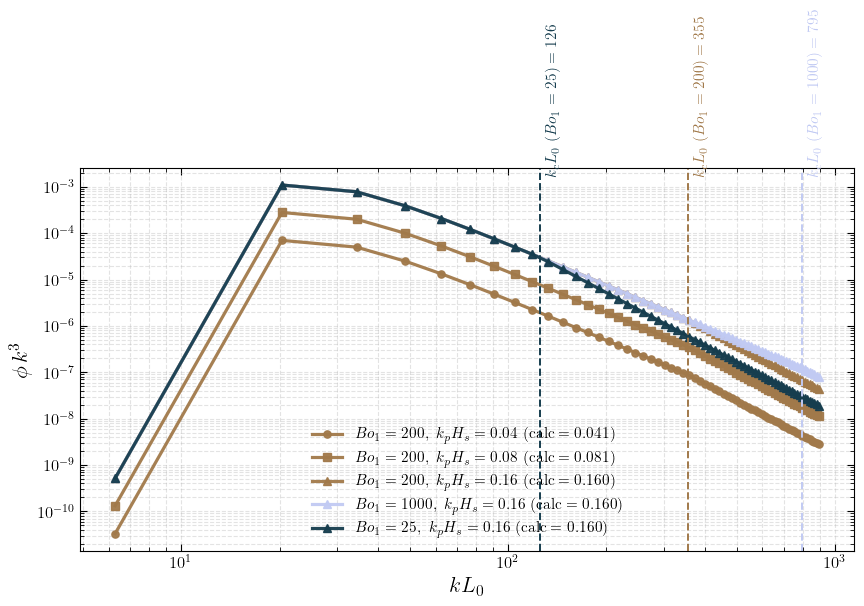

In [41]:
plt.figure(figsize=(8.8, 6.2))
plt.rcParams['font.family'] = 'serif'

bo1_values = sorted(set(c["Bo1"] for c in all_results))
bo1_to_color = {b: col for b, col in zip(bo1_values, plt.cm.cubehelix(np.linspace(0.2, 0.8, len(bo1_values))))}

unique_Ps = list(dict.fromkeys([c["P"] for c in all_results]))
MARKERS = ['o', 's', '^', 'D', 'v']
P_to_marker = {P: MARKERS[i % len(MARKERS)] for i, P in enumerate(unique_Ps)}

for c in all_results:
    color = bo1_to_color[c["Bo1"]]
    marker = P_to_marker[c["P"]]
    # ---- etiqueta 100% LaTeX-safe (sin Unicode) ----
    label = rf'$Bo_1={c["Bo1"]},\ k_pH_s={c["kpHs"]:.2f}\ (\mathrm{{calc}}={c["kpHs"]:.3f})$'
    plt.loglog(
        c["kmod"] * L0, c["F_kmod"] * kp**3,
        lw=2.3, marker=marker, ms=5.2, color=color, label=label, alpha=0.95
    )

# líneas k_c por Bo1 (también en math mode y sin Unicode)
for b in bo1_values:
    kcf_L0 = next(c["k_cf"] * L0 for c in all_results if c["Bo1"] == b)
    plt.axvline(kcf_L0, ls='--', color=bo1_to_color[b], lw=1.4)
    plt.text(kcf_L0*1.03, plt.ylim()[1]*0.6,
             rf'$k_cL_0\ (Bo_1={b})={kcf_L0:.0f}$',
             rotation=90, va='bottom', ha='left', fontsize=11, color=bo1_to_color[b])

plt.xlabel(r"$kL_0$", fontsize=16)
plt.ylabel(r"$\phi\,k^3$", fontsize=16)
plt.tick_params(which='both', direction='in', top=True, right=True, labelsize=12)
plt.grid(True, which='both', ls='--', alpha=0.35)
plt.legend(frameon=False, fontsize=11, loc='best', ncol=1)
plt.tight_layout()
plt.savefig("initial_spectra_comparison_bo_groups.pdf", dpi=400, bbox_inches='tight')
plt.show()


/tmp/ipykernel_3360823/1000012769.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap25 = cm.get_cmap('Reds')


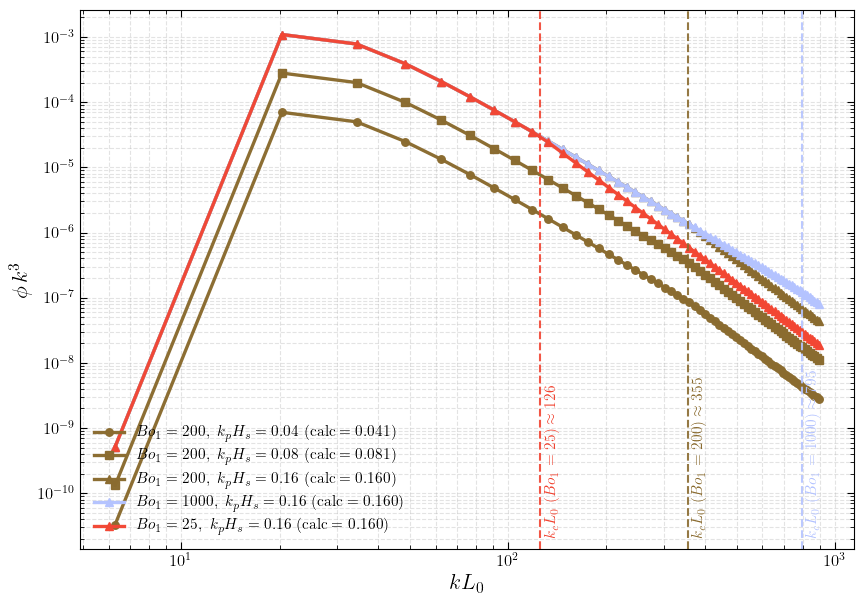

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize

plt.figure(figsize=(8.8, 6.2))
plt.rcParams['font.family'] = 'serif'

# --- grupos por Bo1 ---
bo1_values = sorted(set(c["Bo1"] for c in all_results))
# Colores base para los grupos que NO son Bo1=25
bo1_base_colors = {
    200: '#8a6b2f',   # marrón dorado
    1000:'#b4c3ff',   # azul lavanda claro
}
# fallback para cualquier otro Bo1 (si apareciera)
default_palette = plt.cm.cubehelix(np.linspace(0.25, 0.75, len(bo1_values)))

# --- preparar normalización por kpHs para Bo1=25 ---
bo25 = [c for c in all_results if c["Bo1"] == 25]
if len(bo25) >= 2:
    kpHs_vals_25 = np.array([c["kpHs"] for c in bo25])
    norm25 = Normalize(vmin=kpHs_vals_25.min(), vmax=kpHs_vals_25.max())
else:
    # caso único: rojo medio
    norm25 = Normalize(vmin=0.1, vmax=0.2)  # rango ficticio; dará ~0.5
cmap25 = cm.get_cmap('Reds')

# --- marcadores por P (para distinguir energías dentro de cada Bo1) ---
unique_Ps = list(dict.fromkeys([c["P"] for c in all_results]))
MARKERS = ['o', 's', '^', 'D', 'v', 'P', '*']
P_to_marker = {P: MARKERS[i % len(MARKERS)] for i, P in enumerate(unique_Ps)}

# --- trazar curvas ---
for c in all_results:
    marker = P_to_marker[c["P"]]

    if c["Bo1"] == 25:
        # color rojo según kpHs
        color = cmap25(norm25(c["kpHs"]))
    else:
        # color fijo por Bo1 (si no está en diccionario, usa palette por orden)
        if c["Bo1"] in bo1_base_colors:
            color = bo1_base_colors[c["Bo1"]]
        else:
            idx = bo1_values.index(c["Bo1"])
            color = default_palette[idx]

    label = rf'$Bo_1={c["Bo1"]},\ k_pH_s= {c["kpHs"]:.2f}\ (\mathrm{{calc}}={c["kpHs"]:.3f})$'
    plt.loglog(
        c["kmod"] * L0, c["F_kmod"] * kp**3,
        lw=2.4, marker=marker, ms=5.4, color=color, alpha=0.98,
        label=label
    )

# --- columnas k_cL0 y etiquetas ABAJO dentro del eje ---
ax = plt.gca()
ymin, ymax = ax.get_ylim()
y_text = ymin * (10**0.15)  # un poco por encima del borde inferior (log)

for b in bo1_values:
    # x de la columna
    kcf_L0 = next(c["k_cf"] * L0 for c in all_results if c["Bo1"] == b)

    # color de la columna: coincide con el grupo (para 25 usamos un rojo medio)
    if b == 25:
        col_line = cmap25(0.6)
    elif b in bo1_base_colors:
        col_line = bo1_base_colors[b]
    else:
        idx = bo1_values.index(b)
        col_line = default_palette[idx]

    ax.axvline(kcf_L0, ls='--', color=col_line, lw=1.5, alpha=0.9)

    # etiqueta vertical en la parte baja, dentro del área
    ax.text(kcf_L0*1.02, y_text,
            rf'$k_cL_0\ (Bo_1={b})\approx {kcf_L0:.0f}$',
            rotation=90, va='bottom', ha='left', fontsize=11, color=col_line)

# --- formato ---
plt.xlabel(r"$kL_0$", fontsize=16)
plt.ylabel(r"$\phi\,k^3$", fontsize=16)
plt.tick_params(which='both', direction='in', top=True, right=True, labelsize=12)
plt.grid(True, which='both', ls='--', alpha=0.35)
plt.legend(frameon=False, fontsize=11, loc='lower left')  # leyenda abajo-izq
plt.tight_layout()
plt.savefig("initial_spectra_comparison_bo_groups_reds25.pdf", dpi=400, bbox_inches='tight')
plt.show()


/tmp/ipykernel_3360823/2341676586.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap25 = cm.get_cmap('Reds')
/tmp/ipykernel_3360823/2341676586.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  bo200_colors = [cm.get_cmap('YlOrBr')(v) for v in (0.45, 0.68, 0.88)]


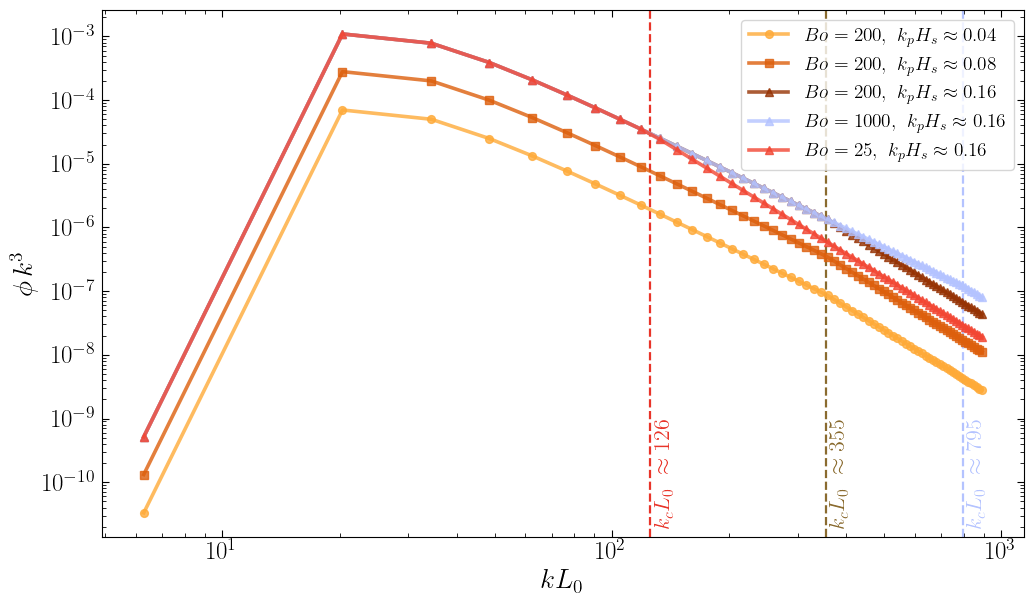

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize, ListedColormap

plt.figure(figsize=(10.5, 6.2))
plt.rcParams['font.family'] = 'serif'

# --- Colores por grupo ---
COLOR_1000 = '#b4c3ff'  # fijo para Bo1=1000

# Bo1=25: gradiente Reds por kpHs
bo25 = [c for c in all_results if c["Bo1"] == 25]
cmap25 = cm.get_cmap('Reds')
if len(bo25) >= 2:
    kpHs_vals_25 = np.array([c["kpHs"] for c in bo25])
    norm25 = Normalize(vmin=kpHs_vals_25.min(), vmax=kpHs_vals_25.max())
else:
    norm25 = Normalize(vmin=0.1, vmax=0.2)

# Bo1=200: tres colores distintos (familia YlOrBr dorado/marrón)
bo200 = [c for c in all_results if c["Bo1"] == 200]
# 3 tonos separados para buen contraste
bo200_colors = [cm.get_cmap('YlOrBr')(v) for v in (0.45, 0.68, 0.88)]
# si prefieres hex fijos: ['#8a6b2f','#a87e39','#c89a3f']
# asignamos por orden de aparición de los casos Bo1=200
for col, c in zip(bo200_colors, bo200):
    c['_fixed_color'] = col  # guardamos color elegido para ese caso

# --- marcadores por P ---
unique_Ps = list(dict.fromkeys([c["P"] for c in all_results]))
MARKERS = ['o', 's', '^', 'D', 'v', 'P', '*']
P_to_marker = {P: MARKERS[i % len(MARKERS)] for i, P in enumerate(unique_Ps)}

# --- trazar curvas ---
for c in all_results:
    marker = P_to_marker[c["P"]]

    if c["Bo1"] == 25:
        color = cmap25(norm25(c["kpHs"]))
    elif c["Bo1"] == 200:
        color = c.get('_fixed_color', '#8a6b2f')  # uno distinto por caso
    elif c["Bo1"] == 1000:
        color = COLOR_1000
    else:
        color = plt.cm.cubehelix(0.55)

    label = rf'$Bo={c["Bo1"]},\ k_pH_s\approx {c["kpHs"]:.2f}$'
    plt.loglog(
        c["kmod"] * L0, c["F_kmod"] * kp**3,
        lw=2.6, marker=marker, ms=5.6, color=color, alpha=0.8, zorder=3, label=label
    )

# --- columnas k_cL0 con etiqueta abajo ---
ax = plt.gca()
ymin, ymax = ax.get_ylim()
y_text = ymin * (10**0.12)

def kc_color(Bo1):
    if Bo1 == 25:   return cmap25(0.65)
    if Bo1 == 200:  return '#8a6b2f'  # color “referencia” del grupo
    if Bo1 == 1000: return COLOR_1000
    return 'k'

bo1_values = sorted(set(c["Bo1"] for c in all_results))
for b in bo1_values:
    kcf_L0 = next(c["k_cf"] * L0 for c in all_results if c["Bo1"] == b)
    col = kc_color(b)
    ax.axvline(kcf_L0, ls='--', color=col, lw=1.6, alpha=1.0, zorder=2)
    ax.text(kcf_L0*1.02, y_text,
            rf'$k_cL_0\ \approx {kcf_L0:.0f}$',
            rotation=90, va='bottom', ha='left', fontsize=16, color=col)

# --- formato ---
plt.xlabel(r"$kL_0$", fontsize=20)
plt.ylabel(r"$\phi\,k^3$", fontsize=20)
plt.tick_params(which='both', direction='in', top=True, right=True, labelsize=18)
#plt.grid(True, which='both', ls='--', alpha=0.35, zorder=0)
plt.legend(frameon=True, fontsize=14, loc='upper right')
plt.tight_layout()
plt.savefig("initial_spectra_comparison_bo200_multi_reds25.pdf", dpi=400, bbox_inches='tight')
plt.show()


/tmp/ipykernel_3360823/959049635.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap25 = cm.get_cmap('Reds')
/tmp/ipykernel_3360823/959049635.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  bo200_colors = [cm.get_cmap('YlOrBr')(v) for v in (0.45, 0.68, 0.88)]


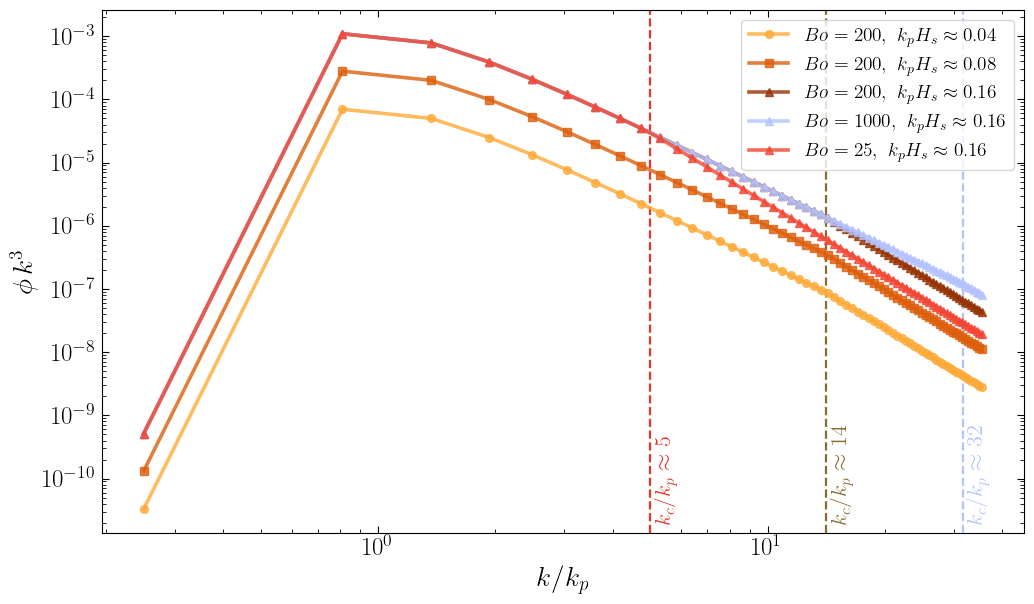

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize

plt.figure(figsize=(10.5, 6.2))
plt.rcParams['font.family'] = 'serif'

# --- Colores por grupo ---
COLOR_1000 = '#b4c3ff'  # fijo para Bo1=1000

# Bo1=25: gradiente Reds por kpHs
bo25 = [c for c in all_results if c["Bo1"] == 25]
cmap25 = cm.get_cmap('Reds')
if len(bo25) >= 2:
    kpHs_vals_25 = np.array([c["kpHs"] for c in bo25])
    norm25 = Normalize(vmin=kpHs_vals_25.min(), vmax=kpHs_vals_25.max())
else:
    norm25 = Normalize(vmin=0.1, vmax=0.2)

# Bo1=200: tres colores distintos (familia YlOrBr dorado/marrón)
bo200 = [c for c in all_results if c["Bo1"] == 200]
bo200_colors = [cm.get_cmap('YlOrBr')(v) for v in (0.45, 0.68, 0.88)]
for col, c in zip(bo200_colors, bo200):
    c['_fixed_color'] = col  # guardamos color elegido para ese caso

# --- marcadores por P ---
unique_Ps = list(dict.fromkeys([c["P"] for c in all_results]))
MARKERS = ['o', 's', '^', 'D', 'v', 'P', '*']
P_to_marker = {P: MARKERS[i % len(MARKERS)] for i, P in enumerate(unique_Ps)}

# --- trazar curvas ---
for c in all_results:
    marker = P_to_marker[c["P"]]

    if c["Bo1"] == 25:
        color = cmap25(norm25(c["kpHs"]))
    elif c["Bo1"] == 200:
        color = c.get('_fixed_color', '#8a6b2f')
    elif c["Bo1"] == 1000:
        color = COLOR_1000
    else:
        color = plt.cm.cubehelix(0.55)

    label = rf'$Bo={c["Bo1"]},\ k_pH_s\approx {c["kpHs"]:.2f}$'
    # --- EJE NORMALIZADO POR k_p ---
    plt.loglog(
        c["kmod"] / kp, c["F_kmod"] * kp**3,
        lw=2.6, marker=marker, ms=5.6,
        color=color, alpha=0.8, zorder=3, label=label
    )

# --- columnas k_c/k_p con etiqueta abajo ---
ax = plt.gca()
ymin, ymax = ax.get_ylim()
y_text = ymin * (10**0.12)

def kc_color(Bo1):
    if Bo1 == 25:   return cmap25(0.65)
    if Bo1 == 200:  return '#8a6b2f'
    if Bo1 == 1000: return COLOR_1000
    return 'k'

bo1_values = sorted(set(c["Bo1"] for c in all_results))
for b in bo1_values:
    # ahora k_c / k_p
    kcf_ratio = next(c["k_cf"] / kp for c in all_results if c["Bo1"] == b)
    col = kc_color(b)
    ax.axvline(kcf_ratio, ls='--', color=col, lw=1.6, alpha=1.0, zorder=2)
    ax.text(kcf_ratio * 1.02, y_text,
            rf'$k_c/k_p \approx {kcf_ratio:.0f}$',
            rotation=90, va='bottom', ha='left', fontsize=16, color=col)

# --- línea vertical en k/kp = 1 ---
#plt.axvline(1.0, ls='-', color='k', lw=1.4, alpha=0.8)
#plt.text(1.05, y_text, r'$k/k_p=1$', rotation=90, va='bottom', ha='left', fontsize=15, color='k')

# --- formato ---
plt.xlabel(r"$k/k_p$", fontsize=20)
plt.ylabel(r"$\phi\,k^3$", fontsize=20)
plt.tick_params(which='both', direction='in', top=True, right=True, labelsize=18)
plt.legend(frameon=True, fontsize=14, loc='upper right')
plt.tight_layout()
plt.savefig("initial_spectra_normalized_by_kp.pdf", dpi=400, bbox_inches='tight')
plt.show()


/tmp/ipykernel_3360823/854805410.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap25 = cm.get_cmap('Reds')
/tmp/ipykernel_3360823/854805410.py:31: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  bo200_palette = [cm.get_cmap('YlOrBr')(v) for v in (0.45, 0.68, 0.88)]


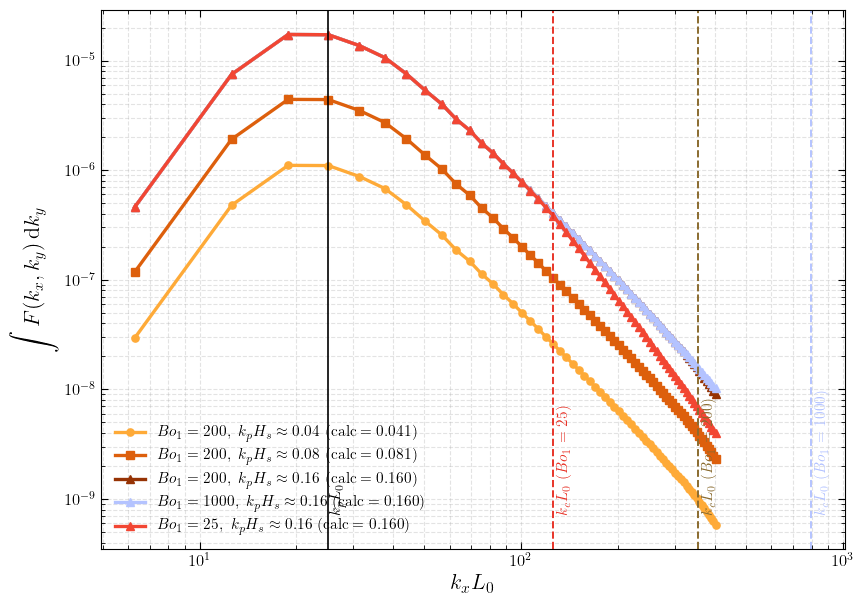

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize

L0 = L  # usa tu L0 (en tu setup L0=L)

# ---------- helpers: obtener F(kx,ky) y colores por caso ----------
def ensure_fkxky(c):
    if all(k in c for k in ("kx", "ky", "F_kxky_tile")):
        return c["kx"], c["ky"], c["F_kxky_tile"]
    # regenerar con tu shape (mismos P, kp, k_cf)
    P = c["P"]; k_cf = c["k_cf"]
    def shape(kmod):  # usa tus funciones importadas
        return spectrum_PM_piece(P, kp, k_cf, kmod)
    _, _, kx, ky, F2D = spectrum_gen_linear(shape, N_mode=N_mode, L=L, N_power=N_power)
    c["kx"], c["ky"], c["F_kxky_tile"] = kx, ky, F2D
    return kx, ky, F2D

# paletas
COLOR_1000 = '#b4c3ff'
cmap25 = cm.get_cmap('Reds')
bo25  = [c for c in all_results if c["Bo1"] == 25]
if len(bo25) >= 2:
    kpHs_vals_25 = np.array([c["kpHs"] for c in bo25])
    norm25 = Normalize(vmin=kpHs_vals_25.min(), vmax=kpHs_vals_25.max())
else:
    norm25 = Normalize(vmin=0.1, vmax=0.2)  # dará rojo medio

bo200 = [c for c in all_results if c["Bo1"] == 200]
bo200_palette = [cm.get_cmap('YlOrBr')(v) for v in (0.45, 0.68, 0.88)]
for col, c in zip(bo200_palette, bo200):
    c["_fixed_color"] = col

def case_color(c):
    if c["Bo1"] == 25:
        return cmap25(norm25(c["kpHs"]))
    if c["Bo1"] == 200:
        return c.get("_fixed_color", '#8a6b2f')
    if c["Bo1"] == 1000:
        return COLOR_1000
    return plt.cm.cubehelix(0.55)

# ---------- integrar en ky y graficar ----------
plt.figure(figsize=(8.8, 6.2))
plt.rcParams['font.family'] = 'serif'

# marcadores por P (opcional, para distinguir energías)
unique_Ps = list(dict.fromkeys([c["P"] for c in all_results]))
MARKERS = ['o', 's', '^', 'D', 'v', 'P', '*']
P_to_marker = {P: MARKERS[i % len(MARKERS)] for i, P in enumerate(unique_Ps)}

for c in all_results:
    kx, ky, F2D = ensure_fkxky(c)
    # integración en ky (trapecios) -> función de kx
    Sx = np.trapz(F2D, ky, axis=0)   # shape: (len(kx),)

    color  = case_color(c)
    marker = P_to_marker[c["P"]]
    label  = rf'$Bo_1={c["Bo1"]},\ k_pH_s\approx {c["kpHs"]:.2f}\ (\mathrm{{calc}}={c["kpHs"]:.3f})$'

    plt.loglog(kx * L0, np.maximum(Sx, 1e-30),
               lw=2.4, marker=marker, ms=5.2, color=color, alpha=1.0, label=label)

# guías en kp y kc (una kc por cada Bo1)
plt.axvline(kp*L0, ls='-', color='k', lw=1.2)
plt.text(kp*L0*1.02, plt.ylim()[0]*2.0, r'$k_pL_0$', rotation=90, va='bottom', fontsize=11, color='k')

bo1_values = sorted(set(c["Bo1"] for c in all_results))
def kc_color(Bo1):
    if Bo1 == 25:   return cmap25(0.65)
    if Bo1 == 200:  return '#8a6b2f'
    if Bo1 == 1000: return COLOR_1000
    return 'k'

y_text = plt.ylim()[0]*2.0
for b in bo1_values:
    kcf_L0 = next(c["k_cf"] * L0 for c in all_results if c["Bo1"] == b)
    col = kc_color(b)
    plt.axvline(kcf_L0, ls='--', color=col, lw=1.4)
    plt.text(kcf_L0*1.02, y_text, rf'$k_cL_0\ (Bo_1={b})$', rotation=90, va='bottom', fontsize=11, color=col)

plt.xlabel(r'$k_xL_0$', fontsize=16)
plt.ylabel(r'$\displaystyle \int F(k_x,k_y)\,\mathrm{d}k_y$', fontsize=16)
plt.tick_params(which='both', direction='in', top=True, right=True, labelsize=12)
plt.grid(True, which='both', ls='--', alpha=0.35)
plt.legend(frameon=False, fontsize=11, loc='best')
plt.tight_layout()
plt.show()


/tmp/ipykernel_3360823/319443227.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap25 = cm.get_cmap('Reds')
/tmp/ipykernel_3360823/319443227.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  bo200_palette = [cm.get_cmap('YlOrBr')(v) for v in (0.45, 0.68, 0.88)]


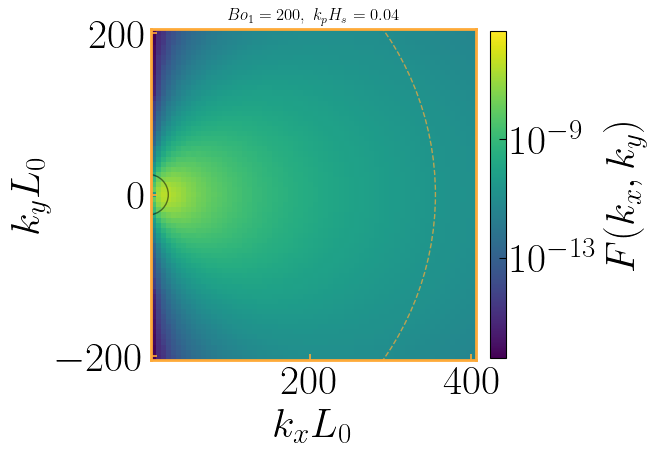

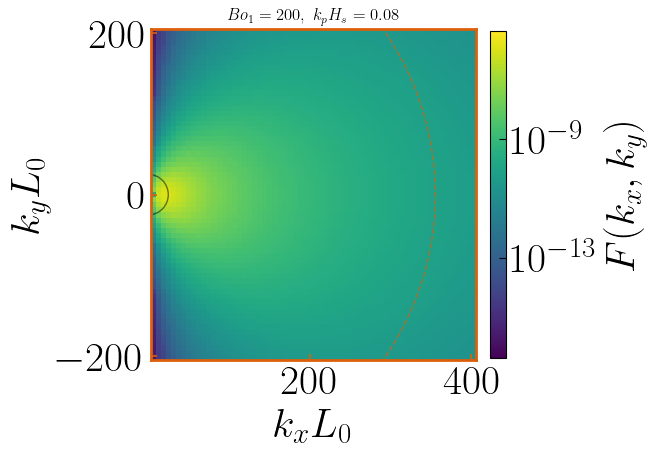

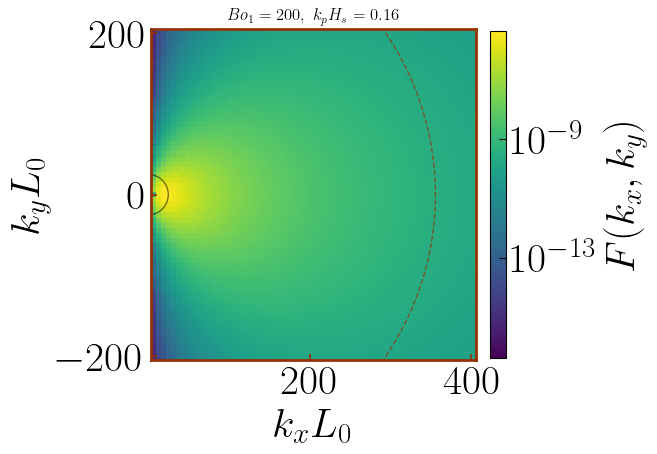

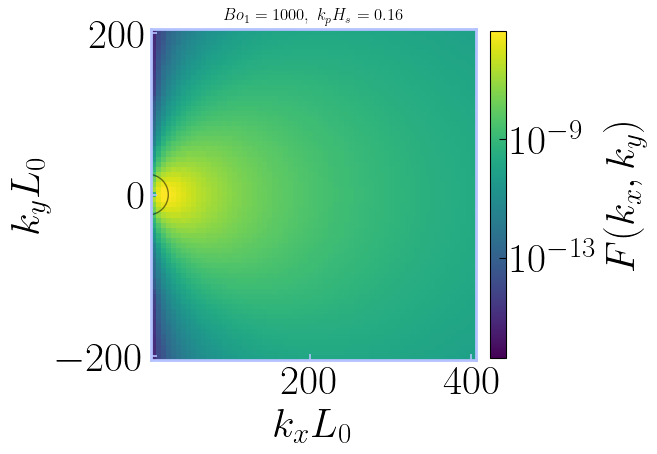

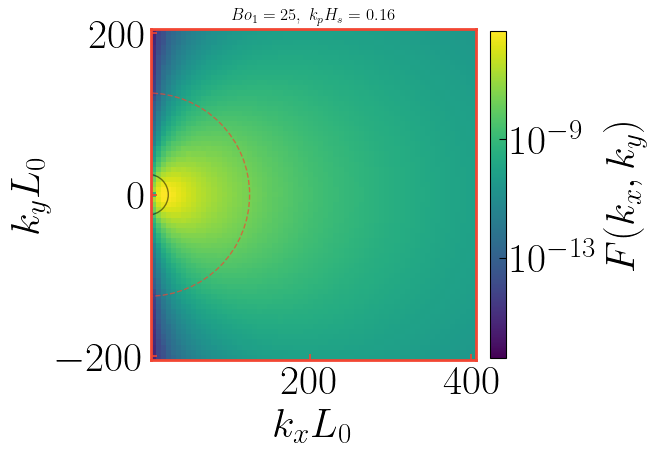

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib import cm
from matplotlib.patches import Circle

# -------- colores por caso (mismos criterios que antes) --------
COLOR_1000 = '#b4c3ff'  # fijo para Bo1=1000
cmap25 = cm.get_cmap('Reds')

bo25 = [c for c in all_results if c["Bo1"] == 25]
if len(bo25) >= 2:
    vmin25 = min(c["kpHs"] for c in bo25)
    vmax25 = max(c["kpHs"] for c in bo25)
else:
    vmin25, vmax25 = 0.1, 0.2  # rango ficticio (dará rojo medio)

bo200 = [c for c in all_results if c["Bo1"] == 200]
# 3 tonos dorado/marrón bien separados (orden: según aparición en all_results)
bo200_palette = [cm.get_cmap('YlOrBr')(v) for v in (0.45, 0.68, 0.88)]
for col, c in zip(bo200_palette, bo200):
    c["_fixed_color"] = col

def case_color(c):
    if c["Bo1"] == 25:
        # gradiente en función de kpHs
        t = (c["kpHs"] - vmin25) / (vmax25 - vmin25 + 1e-12)
        return cmap25(np.clip(t, 0, 1))
    if c["Bo1"] == 200:
        return c.get("_fixed_color", '#8a6b2f')
    if c["Bo1"] == 1000:
        return COLOR_1000
    return plt.cm.cubehelix(0.55)

# -------- asegurar que tenemos kx, ky, F_kxky_tile por caso --------
def ensure_fkxky(c):
    if all(k in c for k in ("kx", "ky", "F_kxky_tile")):
        return c["kx"], c["ky"], c["F_kxky_tile"]
    # regenerar con tu shape
    P = c["P"]
    k_cf = c["k_cf"]
    def shape(kmod):  # usa tus funciones importadas
        return spectrum_PM_piece(P, kp, k_cf, kmod)
    kmod, F_kmod, kx, ky, F_kxky_tile = spectrum_gen_linear(shape, N_mode=N_mode, L=L, N_power=N_power)
    c["kx"], c["ky"], c["F_kxky_tile"] = kx, ky, F_kxky_tile
    return kx, ky, F_kxky_tile

# -------- normalización común (log) para todos los mapas --------
EPS = 1e-30
global_min, global_max = np.inf, -np.inf
for c in all_results:
    _, _, F2D = ensure_fkxky(c)
    f = np.asarray(F2D, dtype=float)
    f = f[f > 0]  # solo positivos para LogNorm
    if f.size:
        global_min = min(global_min, f.min())
        global_max = max(global_max, f.max())
# evita problemas si hay valores muy pequeños
global_min = max(global_min, 1e-30)
norm = LogNorm(vmin=global_min, vmax=global_max)

# -------- plots: SOLO F(kx,ky), marco teñido por color de caso --------
for c in all_results:
    kx, ky, F2D = ensure_fkxky(c)
    col = case_color(c)

    fig, ax = plt.subplots(figsize=(6.6, 6.0))
    kx_tile, ky_tile = np.meshgrid(kx*L, ky*L, indexing='xy')  # ejes en kL0 (L0=L)
    im = ax.pcolormesh(kx_tile, ky_tile, np.maximum(F2D, EPS), norm=norm,
                       cmap='viridis', shading='auto')
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel(r'$k_xL_0$')
    ax.set_ylabel(r'$k_yL_0$')

    # Marco (spines) y ticks con el color del caso
    for sp in ax.spines.values():
        sp.set_color(col); sp.set_linewidth(2.0)
    ax.tick_params(which='both', color=col, length=4, width=1.2)
    # deja las etiquetas numéricas en negro para legibilidad
    for tick in ax.get_xticklabels()+ax.get_yticklabels():
        tick.set_color('black')

    # (Opcional) círculos guía muy sutiles en k_p y k_c — comenta si no los quieres
    ax.add_patch(Circle((0,0), radius=kp*L,   fill=False, ls='-',  lw=1.0, ec='k', alpha=0.5))
    ax.add_patch(Circle((0,0), radius=c["k_cf"]*L, fill=False, ls='--', lw=1.0, ec=col, alpha=0.7))

    # título LaTeX-safe
    ax.set_title(rf'$Bo_1={c["Bo1"]},\ k_pH_s = {c["kpHs"]:.2f}$', fontsize=12)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(r'$F(k_x,k_y)$')

    plt.tight_layout()
    plt.show()
